# Matching Markets: When Prices Can't Do the Job

> Computational Analysis of Social Complexity
>
> Fall 2026, Spencer Lyon

**Prerequisites**

- L11.01–L12.01
- Auctions (week 9)
- Graphs (week 3)
- DataFrames and CSV (weeks 1–2)

**Outcomes**

- Define stability and blocking pairs in two-sided matching
- Implement Gale–Shapley deferred acceptance and a stability checker in Python
- Explain proposer-optimality and its market-design consequences
- Analyze a real marketplace dataset from a two-sided perspective

**References**

- [Easley and Kleinberg, Chapter 10: Matching Markets (required)](https://www.cs.cornell.edu/home/kleinber/networks-book/networks-book.pdf)
- [The Prize in Economic Sciences 2012: Stable Allocations and the Practice of Market Design (required)](https://www.nobelprize.org/uploads/2018/06/popular-economicsciences2012.pdf)
- Gale and Shapley (1962), "College Admissions and the Stability of Marriage"
- Roth, *Who Gets What—and Why* (optional)
- *Matchmakers* (Evans and Schmalensee, 2016) (optional)

## You Need a Kidney

- Roughly **100,000 people** are on the U.S. organ-transplant waitlist
- Paying someone for a kidney is a felony in the United States, and organ sales are prohibited nearly everywhere
- Yet thousands of transplants happen each year between people who began as strangers
  - An incompatible donor–patient pair can swap with another pair
  - An algorithm searches for compatible cycles and chains
- Algorithms from the same matching family assign every U.S. medical resident to a hospital and many New York City students to public schools
- Some markets are repugnant to clear with prices—or simply too complex—so we design the **match**
- This marriage of theory and practice earned Alvin Roth and Lloyd Shapley the 2012 Nobel Prize in Economic Sciences

### When a Price Is Not the Answer

- Last time we separated a platform's **price structure** from its **price level**
- But what if the right price is illegal, unacceptable, or not enough to identify who should meet whom?
- A hospital cares which doctor it hires; a doctor cares which hospital hires them
- These are two-sided markets, but the central object is a pair—not a transaction price
- Today we replace willingness-to-pay with **preference rankings**

## Build 1: The Stable Matching Problem

- We have two equally sized sides: doctors $D$ and hospitals $H$
- Every doctor ranks every hospital; every hospital ranks every doctor
- There are **no prices** in this model
- A matching $\mu$ pairs each doctor with one hospital
- A doctor–hospital pair $(d,h)$ is a **blocking pair** when:
  - Doctor $d$ prefers hospital $h$ to $\mu(d)$, **and**
  - Hospital $h$ prefers doctor $d$ to its assigned doctor
- A matching is **stable** when it has no blocking pair

### Stability Is an Equilibrium Concept

- Recall Nash equilibrium from week 8: no player can profitably deviate on their own
- Stability asks a closely related question: can two agents profitably deviate **together**?
- The deviations here are **pairwise**
- If a blocking pair exists, the announced matching is fragile
  - The doctor and hospital would rather abandon it and match with each other
- Stable does not mean fair, unique, or socially optimal
- It means the matching can defend itself against every pairwise objection

### A Tiny Market: Find the Block

- Doctors' rankings:
  - $D_1: H_1 \succ H_2 \succ H_3$
  - $D_2: H_1 \succ H_2 \succ H_3$
  - $D_3: H_2 \succ H_1 \succ H_3$
- Hospitals' rankings:
  - $H_1: D_2 \succ D_1 \succ D_3$
  - $H_2: D_1 \succ D_3 \succ D_2$
  - $H_3: D_3 \succ D_2 \succ D_1$
- Start with $\mu_0 = \{(D_1,H_1),(D_2,H_2),(D_3,H_3)\}$
- Look at $(D_2,H_1)$:
  - $D_2$ prefers $H_1$ to $H_2$
  - $H_1$ prefers $D_2$ to $D_1$
- So $(D_2,H_1)$ is a **blocking pair** and $\mu_0$ is not stable

### Fixing the Match by Hand

- Swap the first two assignments:
  - $\mu_1 = \{(D_1,H_2),(D_2,H_1),(D_3,H_3)\}$
- $D_2$ now has their first choice
- $D_1$ wants $H_1$, but $H_1$ prefers its current doctor $D_2$
- $D_3$ wants $H_2$ or $H_1$, but both hospitals prefer their current doctors
- No doctor–hospital pair wants to leave together
- Therefore $\mu_1$ is stable
- Checking every pair works for $3 \times 3$; we need an algorithm for $50 \times 50$

## Build 2: Deferred Acceptance

- Gale and Shapley's deferred-acceptance algorithm proceeds in rounds
  1. Each unmatched proposer proposes to their best choice that has not rejected them
  2. Each receiver tentatively holds its best offer so far and rejects the rest
  3. Rejected proposers try their next choice
  4. Repeat until no proposer is unmatched
- **Tentative** is doing important work: a receiver may trade up later
- The process must stop because no proposer visits the same receiver twice
- The remarkable result: it always stops at a stable matching

In [1]:
import numpy as np
from numpy.random import default_rng
import matplotlib.pyplot as plt
import pandas as pd
import urllib.request
import urllib.error
import os

rng = default_rng(6318)

### Rankings as Matrices

- Each row of a preference matrix lists options from best to worst
- Algorithms also need the inverse representation: the rank assigned to each option
- Example: if row 0 is `[1, 0, 2]`, option 1 has rank 0 and option 0 has rank 1
- We will keep both representations because each makes a different operation simple

In [2]:
doctor_prefs = np.array([
    [0, 1, 2],
    [0, 1, 2],
    [1, 0, 2],
])

hospital_prefs = np.array([
    [1, 0, 2],
    [0, 2, 1],
    [2, 1, 0],
])

Note: options are 0-indexed here, following Python convention; the rankings themselves are unchanged.

In [3]:
def preference_ranks(preferences):
    n_people, n_options = preferences.shape
    ranks = np.zeros((n_people, n_options), dtype=int)
    for person in range(n_people):
        for rank, option in enumerate(preferences[person, :]):
            ranks[person, option] = rank
    return ranks


doctor_rank = preference_ranks(doctor_prefs)
hospital_rank = preference_ranks(hospital_prefs)

### Hand-Coding the Algorithm

- `held_by_receiver[h]` records the proposer tentatively held by receiver $h$ (`-1` when empty)
- `next_choice[d]` records where proposer $d$ should apply next
- Our queue contains proposers who are currently unmatched
- Rejection sends a proposer to the back of that queue

In [4]:
def deferred_acceptance(proposer_prefs, receiver_rank):
    n_proposers, n_receivers = proposer_prefs.shape
    if n_proposers != n_receivers:
        raise ValueError("This version expects equal sides")
    if receiver_rank.shape != (n_receivers, n_proposers):
        raise ValueError("Rank dimensions do not match")

    next_choice = np.zeros(n_proposers, dtype=int)
    held_by_receiver = np.full(n_receivers, -1, dtype=int)
    proposal_queue = list(range(n_proposers))
    queue_head = 0

    while queue_head < len(proposal_queue):
        proposer = proposal_queue[queue_head]
        queue_head += 1
        if next_choice[proposer] >= n_receivers:
            raise RuntimeError("A proposer exhausted all choices")

        receiver = proposer_prefs[proposer, next_choice[proposer]]
        next_choice[proposer] += 1
        incumbent = held_by_receiver[receiver]

        if incumbent == -1:
            held_by_receiver[receiver] = proposer
        elif receiver_rank[receiver, proposer] < receiver_rank[receiver, incumbent]:
            held_by_receiver[receiver] = proposer
            proposal_queue.append(incumbent)
        else:
            proposal_queue.append(proposer)

    matching = np.zeros(n_proposers, dtype=int)
    for receiver in range(n_receivers):
        matching[held_by_receiver[receiver]] = receiver
    return matching

In [5]:
mu_tiny = deferred_acceptance(doctor_prefs, hospital_rank)
list(zip(["D1", "D2", "D3"], [f"H{h + 1}" for h in mu_tiny]))

[('D1', 'H2'), ('D2', 'H1'), ('D3', 'H3')]

In [6]:
def is_stable(matching, proposer_rank, receiver_rank):
    n = len(matching)
    if sorted(matching) != list(range(n)):
        return False

    receiver_partner = np.zeros(n, dtype=int)
    for proposer in range(n):
        receiver_partner[matching[proposer]] = proposer

    for proposer in range(n):
        for receiver in range(n):
            current_receiver = matching[proposer]
            current_proposer = receiver_partner[receiver]
            proposer_wants = proposer_rank[proposer, receiver] < proposer_rank[proposer, current_receiver]
            receiver_wants = receiver_rank[receiver, proposer] < receiver_rank[receiver, current_proposer]
            if proposer_wants and receiver_wants:
                return False
    return True

In [7]:
bad_matching = [0, 1, 2]
dict(
    hand_solution=mu_tiny,
    hand_solution_is_stable=is_stable(mu_tiny, doctor_rank, hospital_rank),
    original_match_is_stable=is_stable(bad_matching, doctor_rank, hospital_rank),
)

{'hand_solution': array([1, 0, 2]),
 'hand_solution_is_stable': True,
 'original_match_is_stable': False}

## Scaling Up: A Random $50 \times 50$ Market

- Hand inspection becomes impossible quickly
- We will give every participant an independent random ranking
- Then we will time deferred acceptance and check all $50^2$ possible pairs
- Recall our ABMs: simple local rules can generate an orderly aggregate outcome
- Here repeated proposals and rejections generate global stability

In [8]:
rng = default_rng(6318)
n = 50


def random_preferences(n, rng):
    return np.array([rng.permutation(n) for _ in range(n)])


doctor_prefs_50 = random_preferences(n, rng)
hospital_prefs_50 = random_preferences(n, rng)
doctor_rank_50 = preference_ranks(doctor_prefs_50)
hospital_rank_50 = preference_ranks(hospital_prefs_50)

import time

start = time.perf_counter()
mu_50 = deferred_acceptance(doctor_prefs_50, hospital_rank_50)
elapsed_50 = time.perf_counter() - start
dict(stable=is_stable(mu_50, doctor_rank_50, hospital_rank_50), seconds=elapsed_50)

{'stable': True, 'seconds': 0.0002838103100657463}

## Reveal: Who Gets to Propose?

- The algorithm sounds symmetric, but it is not
- Run deferred acceptance twice on the **same market**:
  - Once with doctors proposing
  - Once with hospitals proposing
- Both outcomes will be stable
- When multiple stable matchings exist, each side prefers to control the proposals
- Let's begin with the smallest market where the difference is visible

### Exercise 1: Two Stable Matchings

- Consider this $2 \times 2$ preference profile:
  - $D_1: H_1 \succ H_2$ and $D_2: H_2 \succ H_1$
  - $H_1: D_2 \succ D_1$ and $H_2: D_1 \succ D_2$
- Show that both the diagonal and cross matchings are stable
- Predict: which matching does doctor-proposing deferred acceptance find?
- Which matching does hospital-proposing deferred acceptance find?
- Explain each answer using the absence of a blocking pair

In [9]:
doctor_prefs_2 = np.array([[0, 1], [1, 0]])
hospital_prefs_2 = np.array([[1, 0], [0, 1]])
doctor_rank_2 = preference_ranks(doctor_prefs_2)
hospital_rank_2 = preference_ranks(hospital_prefs_2)

mu_doctors_propose = deferred_acceptance(doctor_prefs_2, hospital_rank_2)
h_to_d = deferred_acceptance(hospital_prefs_2, doctor_rank_2)
mu_hospitals_propose = np.argsort(h_to_d)

dict(doctors_propose=mu_doctors_propose, hospitals_propose=mu_hospitals_propose)

{'doctors_propose': array([0, 1]), 'hospitals_propose': array([1, 0])}

Note: `np.argsort` inverts a permutation for a 1D array of unique indices, and is used here and below
wherever we need to invert a ranking.

In [10]:
def average_rank(matching, rank_matrix):
    return np.mean([rank_matrix[person, matching[person]] for person in range(len(matching))])


dict(
    doctors_propose_stable=is_stable(mu_doctors_propose, doctor_rank_2, hospital_rank_2),
    hospitals_propose_stable=is_stable(mu_hospitals_propose, doctor_rank_2, hospital_rank_2),
    doctor_ranks=(
        average_rank(mu_doctors_propose, doctor_rank_2),
        average_rank(mu_hospitals_propose, doctor_rank_2),
    ),
    hospital_ranks=(
        average_rank(np.argsort(mu_doctors_propose), hospital_rank_2),
        average_rank(np.argsort(mu_hospitals_propose), hospital_rank_2),
    ),
)

{'doctors_propose_stable': True,
 'hospitals_propose_stable': True,
 'doctor_ranks': (np.float64(0.0), np.float64(1.0)),
 'hospital_ranks': (np.float64(1.0), np.float64(0.0))}

### Algorithm Design Is Market Power

- Both matchings are stable—but they distribute rank very differently
- Doctor-proposing deferred acceptance gives every doctor their best outcome among all stable matchings
- Hospital-proposing deferred acceptance gives every hospital its best stable outcome
- This is **proposer-optimality**
- The NRMP redesigned its algorithm in 1997 to be applicant-proposing precisely because the choice of proposer matters
- Deferred acceptance is also strategy-proof for proposers: truthful rankings are a dominant strategy for that side
- Recall second-price auctions from week 9: a different mechanism, but the same truthfulness flavor
- A neutral-looking line of algorithm design can shift market power

### Exercise 2: Hospitals Have Capacity

- The real NRMP is many-to-one: a hospital can accept $q_h > 1$ residents
- Modify deferred acceptance so each hospital tentatively holds up to its capacity
- When a hospital is full, it should reject its least-preferred held doctor
- What must the returned matching contain when total capacity exceeds the number of doctors?

In [11]:
def deferred_acceptance_capacities(proposer_prefs, receiver_rank, capacities):
    # TODO: track a collection of tentative matches at each receiver
    # TODO: reject the worst held proposer when capacity is exceeded
    # TODO: return one receiver (or None if unmatched) for each proposer
    return None

### Exercise 3: Measure the Proposer Advantage

- Generate 100 random $20 \times 20$ markets
- Run deferred acceptance from both sides in every market
- Record the average rank achieved by proposers and receivers
- Plot histograms for the two distributions
- Is the proposer advantage present in every realization, or only on average?
- What conclusion would you report to a market designer?

In [12]:
def proposer_advantage_experiment(markets=100, n=20, seed=1202):
    rng = default_rng(seed)
    proposer_average_ranks = []
    receiver_average_ranks = []
    # TODO: generate preferences and run deferred acceptance `markets` times
    # TODO: append each side's average rank into the lists above
    # TODO: make side-by-side histograms and interpret the result
    return proposer_average_ranks, receiver_average_ranks


# Run after completing the TODOs:
# proposer_ranks, receiver_ranks = proposer_advantage_experiment()
None

## Build 3: Platforms Mix Matching and Prices

- Deferred acceptance is useful when prices cannot—or should not—do the job
- Most platforms in the wild combine both instruments
  - Airbnb recommends and ranks listings: **matching**
  - Hosts post nightly rates and guests choose budgets: **prices**
- The platform also manages cross-side network effects between hosts and guests
- Let's use Inside Airbnb data to inspect one local market
- The download is optional: every analysis cell also works offline

In [13]:
airbnb_url = "https://data.insideairbnb.com/united-states/nc/asheville/2025-06-11/visualisations/listings.csv"
airbnb_path = "airbnb_listings.csv"

# Any city CSV from https://insideairbnb.com/get-the-data/ works identically.
if not os.path.isfile(airbnb_path):
    try:
        urllib.request.urlretrieve(airbnb_url, airbnb_path)
    except (urllib.error.URLError, OSError) as err:
        print(f"Warning: Airbnb download unavailable ({err}); continuing in offline mode")

data_available = os.path.isfile(airbnb_path)

In [14]:
airbnb = pd.DataFrame()
if data_available:
    try:
        airbnb = pd.read_csv(airbnb_path, low_memory=False)
    except (OSError, pd.errors.ParserError) as err:
        print(f"Warning: cached Airbnb file could not be read ({err}); continuing in offline mode")
        data_available = False

if data_available:
    airbnb[["name", "host_name", "room_type", "price", "reviews_per_month"]].head(6)
else:
    pd.DataFrame({"status": [f"Offline: place a cached city file at {airbnb_path} to run the lab."]})

## Price Distributions by Room Type

- A shared room and an entire home are not the same product
- Pooling them would confuse composition with price differences
- Prices may also contain missing values or arrive as currency strings
- We will clean the field, drop missing values, and trim only the plot at the 99th percentile
- The original rows remain untouched

In [15]:
def clean_price(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, float)):
        return float(x)
    cleaned = str(x).replace("$", "").replace(",", "")
    try:
        return float(cleaned)
    except ValueError:
        return np.nan


if data_available:
    airbnb["price_clean"] = airbnb["price"].apply(clean_price)
None

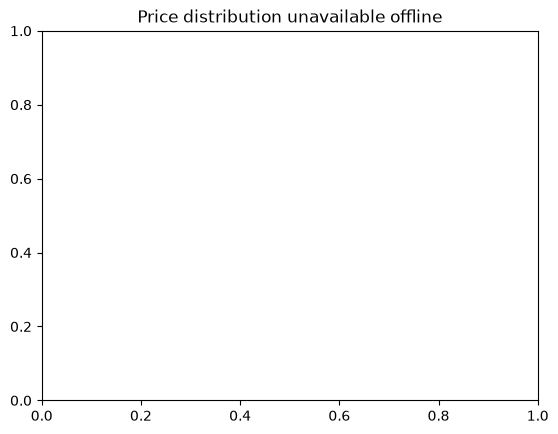

In [16]:
if data_available:
    room_types = sorted(airbnb["room_type"].dropna().unique())
    all_prices = airbnb["price_clean"].dropna().to_numpy()
    price_cap = np.quantile(all_prices, 0.99) if len(all_prices) else 1.0

    fig, ax = plt.subplots()
    ax.set_xlabel("Nightly price (USD)")
    ax.set_ylabel("Listings")
    ax.set_title("Asheville prices by room type")
    for room in room_types:
        room_mask = airbnb["room_type"] == room
        values = airbnb.loc[room_mask, "price_clean"].dropna().to_numpy()
        values = values[(values >= 0) & (values <= price_cap)]
        if len(values):
            ax.hist(values, bins=30, alpha=0.45, label=str(room))
    ax.legend()
    fig
else:
    fig, ax = plt.subplots()
    ax.set_title("Price distribution unavailable offline")
    fig

### Discuss the Price Plot

- Which room type has the highest typical nightly price? Is that surprising?
- Compare spread as well as the center: where is host-side product differentiation strongest?
- The right tail reminds us that a platform hosts several submarkets, not one homogeneous good

## Reviews per Month and Price

- Reviews are an imperfect proxy for booking activity
- Price is an imperfect proxy for quality
- A scatter plot will not identify a demand curve
  - Expensive listings may also be larger, better located, or available less often
- Still, the joint distribution can reveal segmentation and unusual listings
- We again drop missing values explicitly

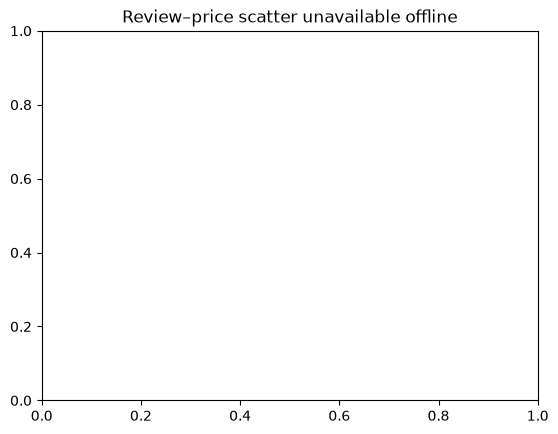

In [17]:
if data_available:
    paired = airbnb[["reviews_per_month", "price_clean"]].dropna()
    review_values = paired["reviews_per_month"].to_numpy()
    scatter_prices = paired["price_clean"].to_numpy()
    review_cap = np.quantile(review_values, 0.99) if len(review_values) else 1.0
    scatter_cap = np.quantile(scatter_prices, 0.99) if len(scatter_prices) else 1.0
    visible = (review_values <= review_cap) & (scatter_prices <= scatter_cap) & (scatter_prices >= 0)

    fig, ax = plt.subplots()
    ax.scatter(review_values[visible], scatter_prices[visible], alpha=0.35, s=9)
    ax.set_xlabel("Reviews per month")
    ax.set_ylabel("Nightly price (USD)")
    ax.set_title("Activity and price")
    fig
else:
    fig, ax = plt.subplots()
    ax.set_title("Review–price scatter unavailable offline")
    fig

### Discuss the Scatter Plot

- Is there a clear relationship, or mostly a cloud?
- Which mechanisms could produce a negative association between price and reviews per month?
- Why would interpreting this picture causally be a mistake? Name at least two omitted variables

## Who Supplies the Listings?

- The original story of Airbnb was peer-to-peer: one host, one spare room, one guest
- But platform growth can invite professional operators
- We will count listings by host and display the largest portfolios
- This is a same-side concentration question nested inside a cross-side marketplace

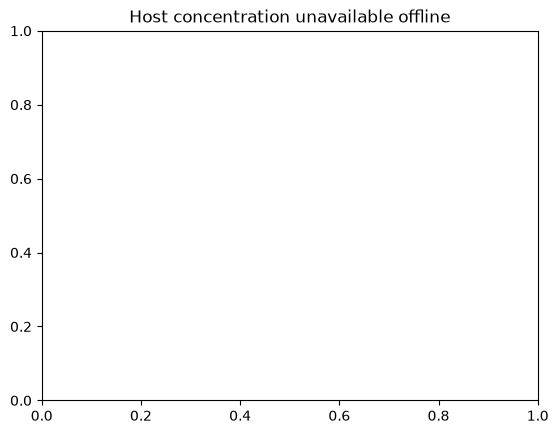

In [18]:
if data_available:
    host_rows = airbnb.dropna(subset=["host_id"])[["host_id", "host_name"]]
    host_counts = (
        host_rows.groupby(["host_id", "host_name"], dropna=False)
        .size()
        .reset_index(name="listing_count")
        .sort_values("listing_count", ascending=False)
    )
    top_hosts = host_counts.head(15)
    labels = [
        f"Host {int(row.host_id)}" if pd.isna(row.host_name) else str(row.host_name)
        for row in top_hosts.itertuples()
    ]

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(list(reversed(labels)), list(reversed(top_hosts["listing_count"])))
    ax.set_xlabel("Number of listings")
    ax.set_ylabel("Host")
    ax.set_title("Largest host portfolios")
    fig
else:
    fig, ax = plt.subplots()
    ax.set_title("Host concentration unavailable offline")
    fig

### Discuss Host Professionalization

- Do the largest portfolios look like occasional home sharing or a professional lodging business?
- How might professional hosts change same-side competition among hosts?
- How might they change cross-side value for guests through consistency, variety, or market power?
- Is Airbnb still peer-to-peer? The answer may depend on whether we describe the technology, the typical host, or the typical listing

### Exercise 4: Quantify Professionalization

- Compute the share of **listings** held by hosts with 10 or more listings
- Also compute the share of **hosts** with 10 or more listings
- Why are these two denominators telling different stories?
- What does your result imply for the platform's "peer-to-peer" framing?

In [19]:
if data_available:
    # TODO: use `host_counts["listing_count"]` from the previous analysis
    # TODO: compute listing share = listings held by 10+ hosts / all listings
    # TODO: compute host share = hosts with 10+ listings / all hosts
    None
else:
    None

## The Platforms Unit in One Slide

- **L11.01:** Platforms create value by connecting sides through same-side / cross-side network effects
- **L11.02:** They solve a chicken-and-egg problem, fight toward critical mass, and may experience tipping
- **L12.01:** They choose price structure as well as price level, often subsidizing one side
- **Today:** They sometimes replace prices with matching algorithms entirely
- **Multihoming** can soften lock-in, but it does not remove the platform's power to rank, recommend, price, or match
- Stable matching shows that the rules connecting agents determine who benefits—even when no money changes hands
- Matchmaking is the oldest business model—and maybe the newest: GPU and model marketplaces are two-sided markets for intelligence itself

## Closing the Semester

- We began with networks: who is connected to whom?
- We added games: how do incentives shape choices?
- We built ABMs: how do simple local rules create emergent outcomes?
- We studied agents: how do decision-makers perceive, act, and adapt?
- We ended with platforms and matching: who writes the rules that connect everyone?
- Across the semester, one question kept returning:
  - **How do individual choices aggregate into collective outcomes?**
- Your final project is your chance to answer that question for a system you care about
- Thank you for bringing your questions, code, and ideas to the course
- Next time is yours: the final project is where you design the model, run the computation, and tell us what the collective outcome means